# Ecommerce Growth Analytics — Executive Summary

**Dataset:** 10,000 users · 2,000 products · 10 categories · Jan 2024 – Nov 2025  
**Data sources:** `events` (behavioral intent) + `orders` / `order_items` (actual revenue)

---

## Business Problem

> Users do not progress from low-intent behavior (views) to high-intent actions (cart, wishlist), resulting in weak conversion to purchase. On top of that, most new users never return after their first visit — so the acquisition cost is essentially wasted on 72% of incoming traffic.

This notebook answers: **where exactly does the platform lose users, why, and what does the revenue impact look like?**

In [1]:
from src.db import run_sql
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

## Platform at a Glance

In [2]:
ub  = run_sql("../sql/user_behavior_mart.sql")
rev = run_sql("../sql/revenue_mart.sql")
rev_buyers = rev[rev['total_orders'] > 0]

total_users    = len(ub)
pct_viewed     = (ub['views_count'] > 0).sum() / total_users * 100
pct_carted     = (ub['cart_adds'] > 0).sum() / total_users * 100
pct_purchased  = (ub['purchase_events'] > 0).sum() / total_users * 100
total_revenue  = rev_buyers['total_spent'].sum()
avg_aov        = rev_buyers['avg_order_value'].mean()
pct_buyers_rev = len(rev_buyers) / total_users * 100

print(f"Total users:              {total_users:,}")
print(f"Users who viewed:         {pct_viewed:.1f}%")
print(f"Users who added to cart:  {pct_carted:.1f}%")
print(f"Users who purchased:      {pct_purchased:.1f}%  ← only 1 in 3")
print(f"")
print(f"Total revenue:            ${total_revenue:,.0f}")
print(f"Avg order value:          ${avg_aov:.0f}")
print(f"Buyers (from orders):     {pct_buyers_rev:.1f}% of all users")

Total users:              10,000
Users who viewed:         99.6%
Users who added to cart:  69.9%
Users who purchased:      32.8%  ← only 1 in 3

Total revenue:            $11,918,669
Avg order value:          $594
Buyers (from orders):     86.4% of all users


## 1. The Funnel — Where Users Drop Off

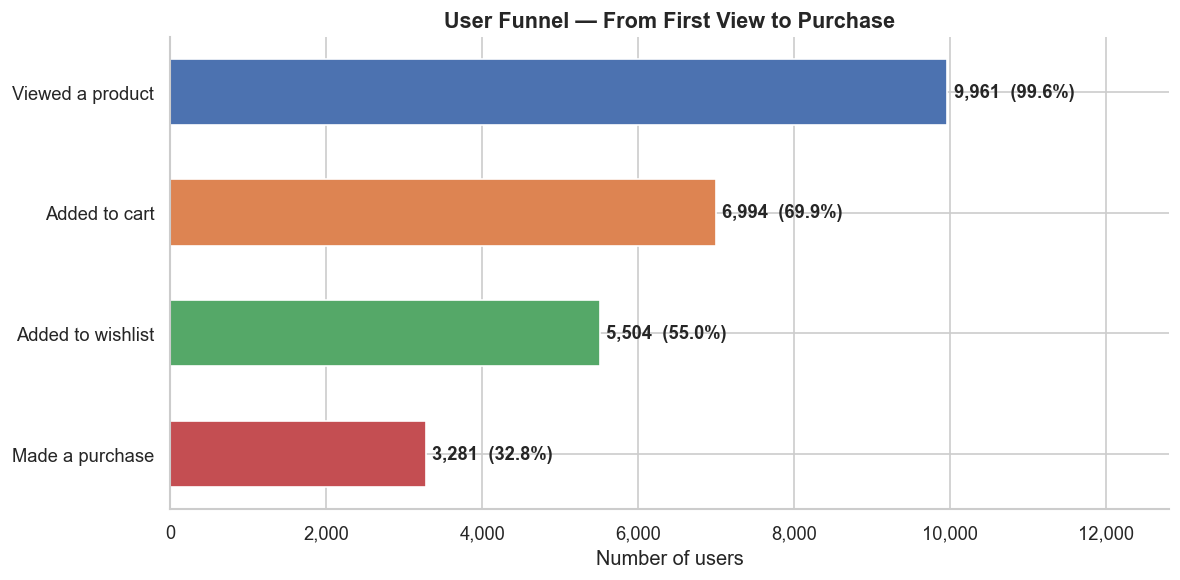

View → Cart:     70.2%  of viewers add to cart
Cart → Purchase: 46.9%  of cart users actually buy
View → Purchase: 32.9%  end-to-end conversion


In [3]:
total   = len(ub)
viewers = (ub['views_count'] > 0).sum()
carted  = (ub['cart_adds'] > 0).sum()
wishd   = (ub['wishlist_adds'] > 0).sum()
bought  = (ub['purchase_events'] > 0).sum()

stages = pd.DataFrame({
    'Stage': ['Viewed a product', 'Added to cart', 'Added to wishlist', 'Made a purchase'],
    'Users': [viewers, carted, wishd, bought],
    'Pct':   [viewers/total*100, carted/total*100, wishd/total*100, bought/total*100]
})

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(stages['Stage'][::-1], stages['Users'][::-1],
               color=colors[::-1], edgecolor='white', height=0.55)
for bar, (_, row) in zip(bars, stages[::-1].iterrows()):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f"{row['Users']:,}  ({row['Pct']:.1f}%)", va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, total * 1.28)
ax.set_xlabel("Number of users")
ax.set_title("User Funnel — From First View to Purchase", fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
plt.show()

print(f"View → Cart:     {carted/viewers*100:.1f}%  of viewers add to cart")
print(f"Cart → Purchase: {bought/carted*100:.1f}%  of cart users actually buy")
print(f"View → Purchase: {bought/viewers*100:.1f}%  end-to-end conversion")

**What this tells us:** The top of the funnel is healthy — 99.6% of users view products. The problem is the bottom. Only 1 in 3 users who views ever buys. The sharpest drop is between wishlist (55%) and purchase (32.8%) — users show clear intent but don't convert. See `02_funnel_analysis.ipynb` for the full breakdown by category.

## 2. Revenue — Who Actually Pays

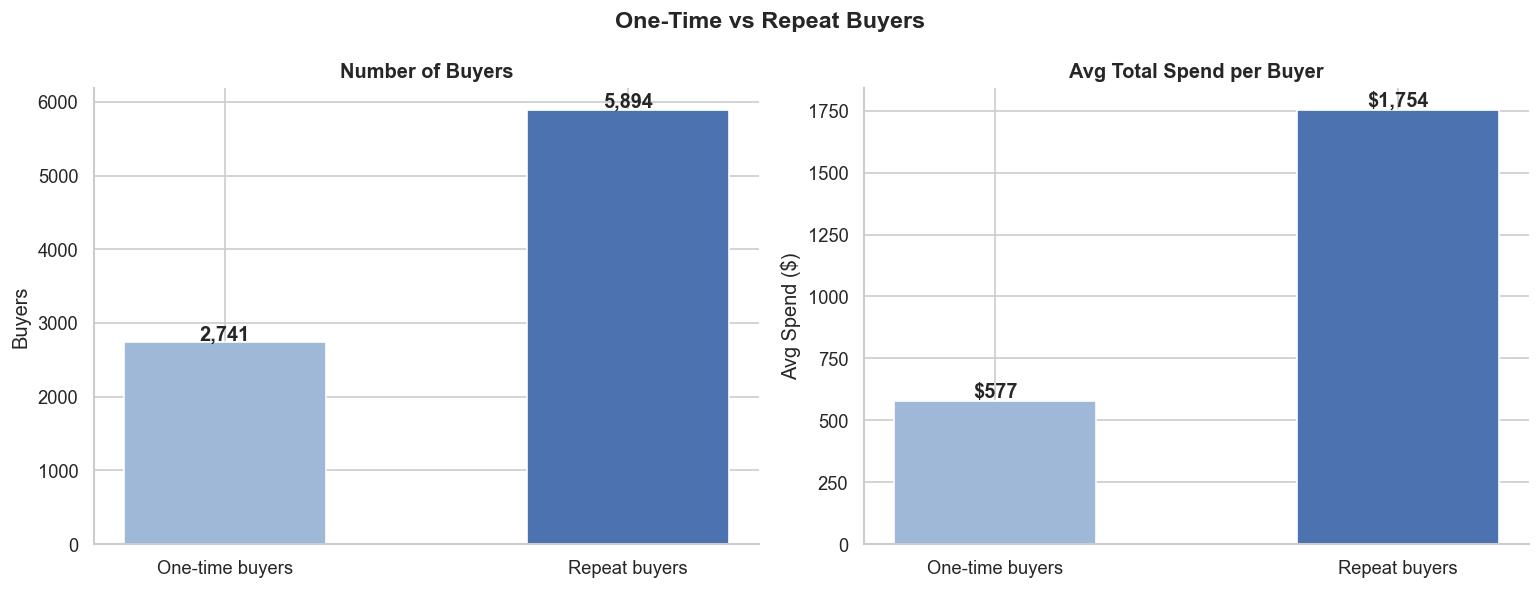

One-time buyers     count: 2,741 (31.7%)  revenue: $1,580,530 (13.3%)  avg: $577
Repeat buyers       count: 5,894 (68.3%)  revenue: $10,338,139 (86.7%)  avg: $1754


In [4]:
one_time = rev_buyers[rev_buyers['total_orders'] == 1]
repeat   = rev_buyers[rev_buyers['total_orders'] > 1]

labels = ['One-time buyers', 'Repeat buyers']
counts = [len(one_time), len(repeat)]
revenues = [one_time['total_spent'].sum(), repeat['total_spent'].sum()]
avg_spends = [one_time['total_spent'].mean(), repeat['total_spent'].mean()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_2 = ['#9FB8D8', '#4C72B0']

bars1 = axes[0].bar(labels, counts, color=colors_2, edgecolor='white', width=0.5)
for bar, val in zip(bars1, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f"{val:,}", ha='center', fontsize=12, fontweight='bold')
axes[0].set_title("Number of Buyers", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Buyers")
sns.despine(ax=axes[0])

bars2 = axes[1].bar(labels, avg_spends, color=colors_2, edgecolor='white', width=0.5)
for bar, val in zip(bars2, avg_spends):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 f"${val:,.0f}", ha='center', fontsize=12, fontweight='bold')
axes[1].set_title("Avg Total Spend per Buyer", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Avg Spend ($)")
sns.despine(ax=axes[1])

fig.suptitle("One-Time vs Repeat Buyers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for label, n, r, a in zip(labels, counts, revenues, avg_spends):
    print(f"{label:<18}  count: {n:,} ({n/len(rev_buyers)*100:.1f}%)  "
          f"revenue: ${r:,.0f} ({r/total_revenue*100:.1f}%)  avg: ${a:.0f}")

**What this tells us:** 68% of buyers are repeat buyers, and they spend on average $1,754 — 3× more than one-time buyers ($577). The platform is heavily dependent on a loyal core. Converting even a fraction of one-time buyers into repeat buyers would have an outsized revenue impact. See `03_revenue_analysis.ipynb` for RFM segmentation.

## 3. Retention — Do Users Come Back?

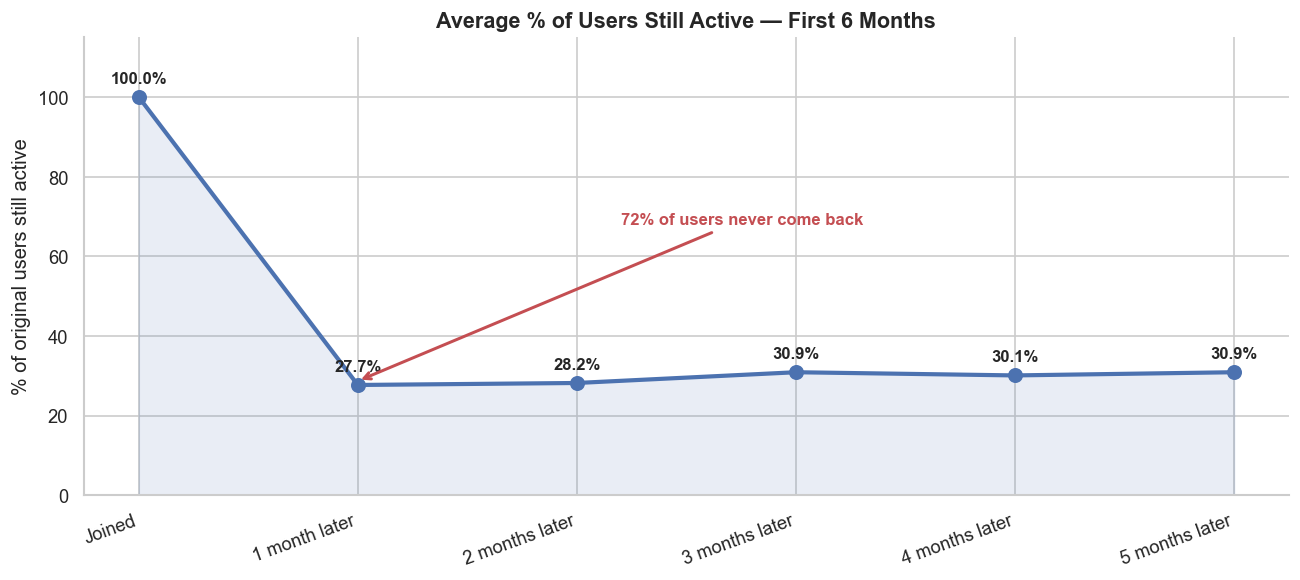

Users active in join month:    100%
Users who return next month:   27.7%
Drop-off after month one:      72% of all new users
Retention months 2-6:          stable at ~29-33%


In [5]:
coh = run_sql("../sql/analysis_cohorts.sql")
coh['cohort_month'] = pd.to_datetime(coh['cohort_month'])

sizes = (coh[coh['cohort_index'] == 0]
         .groupby('cohort_month')['user_id'].nunique()
         .reset_index().rename(columns={'user_id': 'cohort_size'}))
act = (coh.groupby(['cohort_month', 'cohort_index'])['user_id']
       .nunique().reset_index().rename(columns={'user_id': 'active_users'}))
act = act.merge(sizes, on='cohort_month')
act['retention'] = (act['active_users'] / act['cohort_size'] * 100).round(1)

has6 = act[act['cohort_index'] == 5]['cohort_month'].unique()
act6 = act[act['cohort_month'].isin(has6) & (act['cohort_index'] <= 5)]

avg_ret = act6.groupby('cohort_index')['retention'].mean().round(1).reset_index()
avg_ret.columns = ['month_num', 'retention']
avg_ret['label'] = ['Joined', '1 month later', '2 months later',
                    '3 months later', '4 months later', '5 months later']

m0 = avg_ret.loc[0, 'retention']
m1 = avg_ret.loc[1, 'retention']

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(avg_ret))
ax.plot(x, avg_ret['retention'], color='#4C72B0', linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(x, avg_ret['retention'], alpha=0.12, color='#4C72B0')
for i, row in avg_ret.iterrows():
    ax.text(i, row['retention'] + 3.5, f"{row['retention']:.1f}%",
            ha='center', fontsize=10, fontweight='bold')
ax.annotate(
    f"{m0-m1:.0f}% of users never come back",
    xy=(1, m1+1), xytext=(2.2, 68),
    fontsize=10, color='#C44E52', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.8)
)
ax.set_xticks(x)
ax.set_xticklabels(avg_ret['label'], rotation=20, ha='right')
ax.set_title("Average % of Users Still Active — First 6 Months", fontsize=13, fontweight='bold')
ax.set_ylabel("% of original users still active")
ax.set_ylim(0, 115)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Users active in join month:    100%")
print(f"Users who return next month:   {m1:.1f}%")
print(f"Drop-off after month one:      {m0-m1:.0f}% of all new users")
print(f"Retention months 2-6:          stable at ~29-33%")

**What this tells us:** 72% of new users never return after their first month — and this is consistent across all 17 cohorts analyzed. Users who do return are very stable (29–33% active through month 6). The problem is not long-term retention — it's the gap between visit one and visit two. See `05_cohort_analysis.ipynb` for the full cohort breakdown.

---

## Answer to the Business Problem

> *Users do not progress from low-intent behavior (views) to high-intent actions.*

The data confirms this — but reveals two separate problems:

**Problem 1 — Funnel drop at the decision stage.**
Users browse and wishlist freely (99.6% view, 55% wishlist) but only 32.8% purchase. The gap between wishlist and purchase is the biggest single drop in the funnel. Users show intent but something stops them from completing the action — likely price sensitivity, lack of urgency, or UX friction at checkout.

**Problem 2 — First-visit churn.**
72% of new users visit once and never come back. Until that number improves, the conversion problem compounds — there's no second chance to capture users who didn't buy on visit one. The cohort data shows no specific month performed better, which means this is a product experience problem, not a campaign or seasonal issue.

**What's working:**
- Users who return once become reliable long-term buyers
- Repeat buyers (68% of buyers) drive the majority of revenue at $1,754 avg spend
- Electronics drives 41.6% of revenue through pricing, not volume — price is not a conversion barrier

**Where to focus:**
1. Reduce the wishlist-to-purchase drop — test urgency signals, price anchoring, or checkout simplification
2. Improve the first-session experience to increase month-2 return rate from 28% toward 40%+
3. Build re-engagement flows targeting the 72% who left after visit one